In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# load the bead volumes and their xy locations
data_path = "/nfs/data26/chuyu/data/20250505_181137/20250505_181137_bead_volumes_green.h5"
with h5py.File(data_path, "r") as f:
    bead_volumes = f["bead_volumes"][:]
    bead_xy_locations = f["bead_xy_locations"][:]

n_bead, n_z, n_y, n_x = bead_volumes.shape
bead_xy_locations = bead_xy_locations.T
# normalize bead volumes so that their intensities sum to 1
bead_volumes = bead_volumes / np.sum(bead_volumes, axis=(1,2,3), keepdims=True)

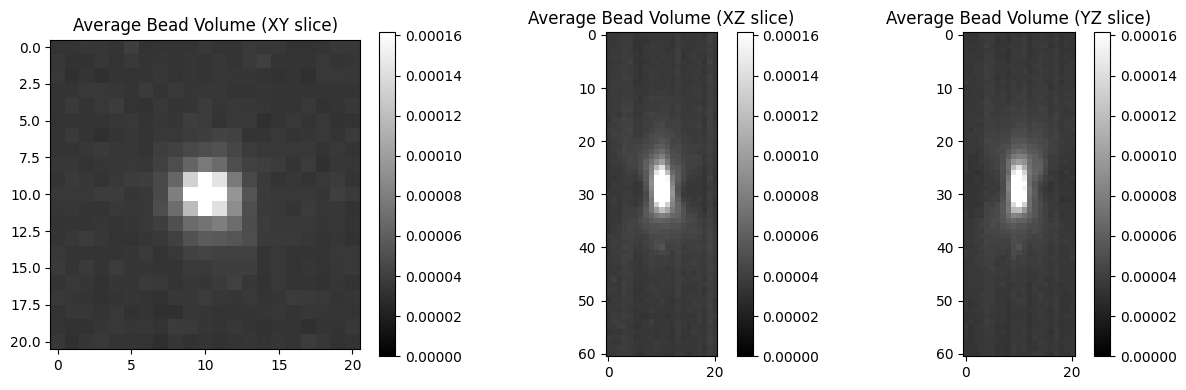

In [6]:
# average bead volume and plot
avg_bead_volume = np.mean(bead_volumes, axis=0)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(avg_bead_volume[n_z//2], cmap='gray', vmin = 0, vmax= np.max(avg_bead_volume)/2)
plt.colorbar()
plt.title('Average Bead Volume (XY slice)')
plt.subplot(1,3,2)
plt.imshow(avg_bead_volume[:, n_y//2, :], cmap='gray', vmin = 0, vmax= np.max(avg_bead_volume)/2)
plt.colorbar()
plt.title('Average Bead Volume (XZ slice)')
plt.subplot(1,3,3)
plt.imshow(avg_bead_volume[:, :, n_x//2], cmap='gray', vmin = 0, vmax= np.max(avg_bead_volume)/2)
plt.colorbar()
plt.title('Average Bead Volume (YZ slice)')
plt.tight_layout()

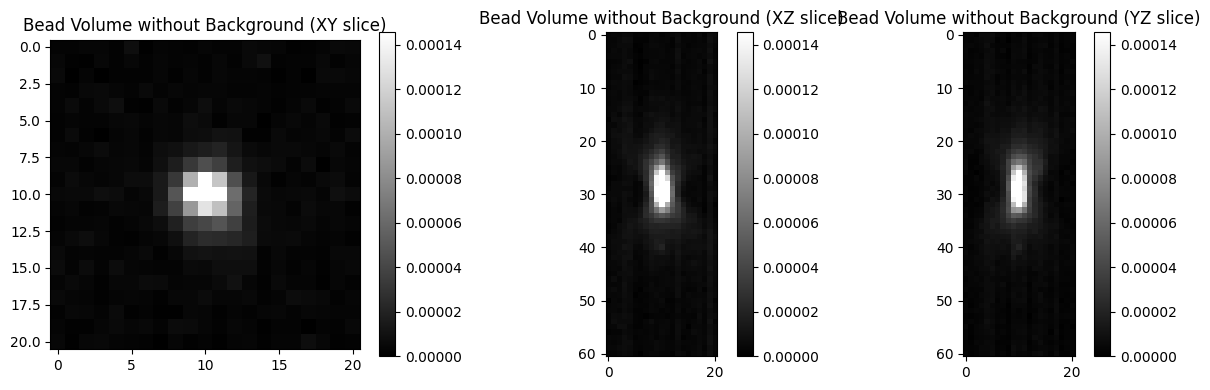

In [8]:
# remove the background by rolling ball
from skimage.morphology import ball, opening
selem = ball(10)
bg_bead_volume = opening(avg_bead_volume, selem)
bead_volume_no_bg = avg_bead_volume - bg_bead_volume
bead_volume_no_bg[bead_volume_no_bg < 0] = 0


# plot bead volume without background
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(bead_volume_no_bg[n_z//2], cmap='gray', vmin = 0, vmax= np.max(bead_volume_no_bg)/2)
plt.colorbar()
plt.title('Bead Volume without Background (XY slice)')
plt.subplot(1,3,2)
plt.imshow(bead_volume_no_bg[:, n_y//2, :], cmap='gray', vmin = 0, vmax= np.max(bead_volume_no_bg)/2)
plt.colorbar()
plt.title('Bead Volume without Background (XZ slice)')
plt.subplot(1,3,3)
plt.imshow(bead_volume_no_bg[:, :, n_x//2], cmap='gray', vmin = 0, vmax= np.max(bead_volume_no_bg)/2)
plt.colorbar()
plt.title('Bead Volume without Background (YZ slice)')
plt.tight_layout()

In [9]:
# save averaged bead as nrrd
import nrrd
nrrd_path = "/nfs/data26/chuyu/data/20250505_181137/20250505_181137_avg_bead_volume.nrrd"
nrrd.write(nrrd_path, bead_volume_no_bg.astype(np.float32))
    

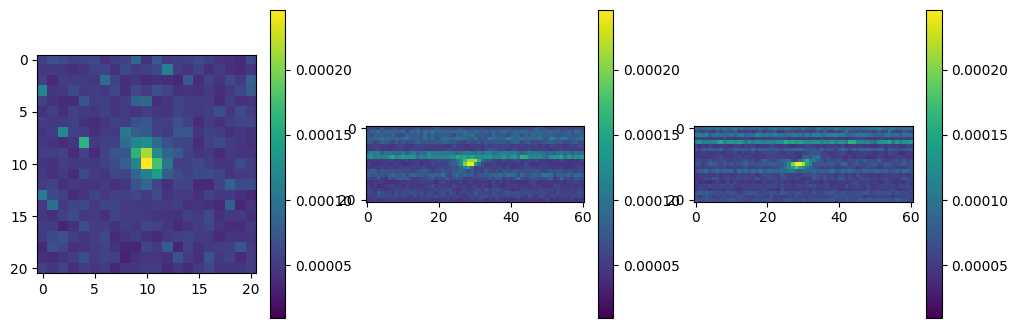

In [26]:
# plot the x, y, z projections of a random bead
which_bead = np.random.choice(n_bead)
bead_volumn = bead_volumes[which_bead, :, :, :]
fig = plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(np.max(bead_volumn, axis=0)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn))
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(np.max(bead_volumn, axis=1)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn))
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(np.max(bead_volumn, axis=2)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn))
plt.colorbar()
plt.show()

In [32]:
# do PCA on the bead volumes and get the loading coefficients and eigen-beads
from sklearn.decomposition import PCA
n_components = 10
bead_volumes_reshaped = bead_volumes.reshape(n_bead, n_z * n_y * n_x)
pca = PCA(n_components=n_components)
pca.fit(bead_volumes_reshaped)
bead_volumes_pca = pca.transform(bead_volumes_reshaped)
eigen_beads = pca.components_.reshape(n_components, n_z, n_y, n_x)

In [33]:
bead_volumes_pca.shape

(43, 10)

In [34]:
bead_volumes_reshaped.shape

(43, 26901)

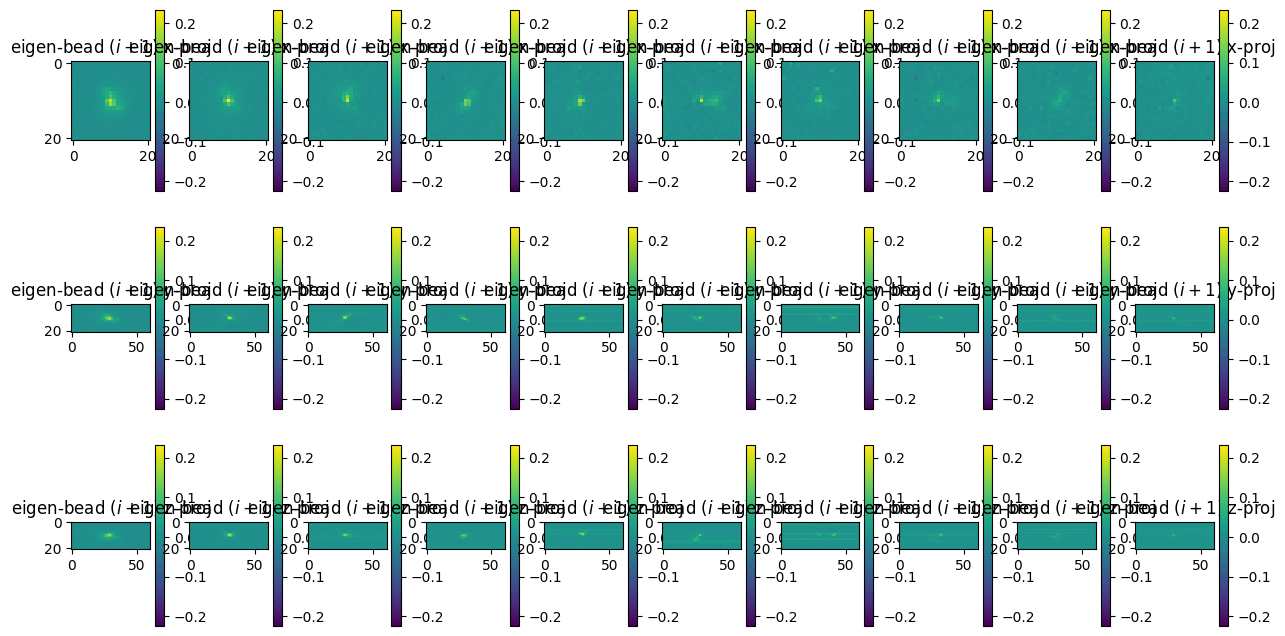

In [35]:
# plot all the eigen-beads as x, y, z projections
fig = plt.figure(figsize=(15,8))
for i in range(n_components):
    plt.subplot(3,n_components,i+1)
    plt.imshow(np.max(eigen_beads[i, :, :, :], axis=0).T, vmin = np.min(eigen_beads), vmax = np.max(eigen_beads))
    plt.title("eigen-bead $(i+1)$ x-proj")
    plt.colorbar()
    plt.subplot(3,n_components,n_components+i+1)
    plt.imshow(np.max(eigen_beads[i, :, :, :], axis=1).T, vmin = np.min(eigen_beads), vmax = np.max(eigen_beads))
    plt.title("eigen-bead $(i+1)$ y-proj")
    plt.colorbar()
    plt.subplot(3,n_components,2*n_components+i+1)
    plt.imshow(np.max(eigen_beads[i, :, :, :], axis=2).T, vmin = np.min(eigen_beads), vmax = np.max(eigen_beads))
    plt.title("eigen-bead $(i+1)$ z-proj")
    plt.colorbar()
plt.show()

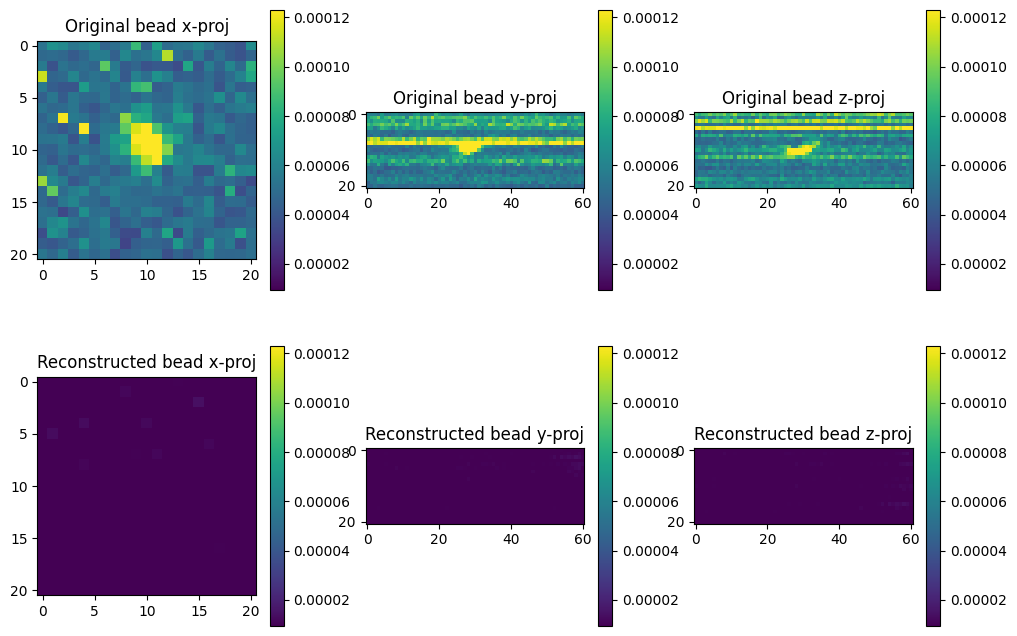

In [76]:
# reconstruct a bead volume using the first 10 PCA components, and plot the projections before and after reconstruction
which_bead = np.random.choice(n_bead)
bead_volumn = bead_volumes[which_bead, :, :, :]
bead_pca_coeffs = bead_volumes_pca[which_bead, :]
bead_reconstructed = np.dot(bead_pca_coeffs, pca.components_).reshape(n_z, n_y, n_x)
fig = plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt.imshow(np.max(bead_volumn, axis=0)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn)/2)
plt.title("Original bead x-proj")
plt.colorbar()
plt.subplot(2,3,2)
plt.imshow(np.max(bead_volumn, axis=1)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn)/2)
plt.title("Original bead y-proj")
plt.colorbar()
plt.subplot(2,3,3)
plt.imshow(np.max(bead_volumn, axis=2)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn)/2)
plt.title("Original bead z-proj")
plt.colorbar()
plt.subplot(2,3,4)
plt.imshow(np.max(bead_reconstructed, axis=0)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn)/2)
plt.title("Reconstructed bead x-proj")
plt.colorbar()
plt.subplot(2,3,5)
plt.imshow(np.max(bead_reconstructed, axis=1)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn)/2)
plt.title("Reconstructed bead y-proj")
plt.colorbar()
plt.subplot(2,3,6)
plt.imshow(np.max(bead_reconstructed, axis=2)[:, :].T, vmin = np.min(bead_volumn), vmax = np.max(bead_volumn)/2)
plt.title("Reconstructed bead z-proj")
plt.colorbar()
plt.show()

In [77]:
import numpy as np
from itertools import combinations

def select_triangle_near_target(calibrated_positions, target, k=6):
    """
    Choose three calibrated positions whose triangle centroid is closest to the target.

    Args:
        calibrated_positions: array-like, shape (N,2) -- x,y positions
        target: array-like length 2 -- x,y target position
        k: int -- number of nearest calibrated positions to consider (must be >= 3)

    Returns:
        selected_indices: list of 3 ints (indices into calibrated_positions)
        centroid: ndarray shape (2,) -- centroid of the selected triangle
        centroid_distance: float -- distance from centroid to target
    """
    pos = np.asarray(calibrated_positions)
    tgt = np.asarray(target)
    if pos.ndim != 2 or pos.shape[1] != 2:  
        raise ValueError('calibrated_positions must be shape (N,2)')
    if tgt.shape != (2,):
        tgt = np.asarray(tgt).ravel()[:2]

    N = pos.shape[0]
    if N < 3:
        raise ValueError('need at least 3 calibrated positions')

    # lateral (xy) distances to target
    dists = np.linalg.norm(pos - tgt, axis=1)

    # clamp k to valid range
    k = int(max(3, min(k, N)))

    # indices of the k nearest positions
    nearest_idx = np.argsort(dists)[:k]

    best = None
    best_centroid = None
    best_dist = np.inf

    # try every triangle from the k nearest positions
    for comb in combinations(nearest_idx, 3):
        tri = pos[list(comb)]
        centroid = tri.mean(axis=0)
        cd = np.linalg.norm(centroid - tgt)
        if cd < best_dist:
            best_dist = cd
            best = comb
            best_centroid = centroid

    return list(best), best_centroid, float(best_dist)  




In [81]:
bead_xy_locations.shape

(2, 43)

(np.float64(-26.400000000000006),
 np.float64(928.4),
 np.float64(-7.800000000000001),
 np.float64(669.8))

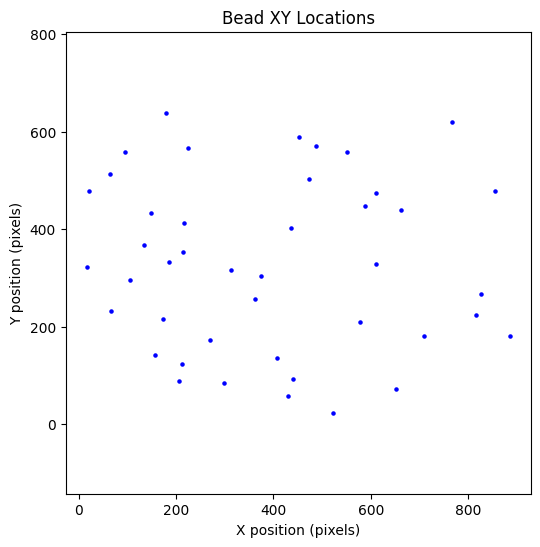

In [83]:
# plot all the bead locations
plt.figure(figsize=(6,6))
plt.scatter(bead_xy_locations[:,0], bead_xy_locations[:,1], s=5, c='blue')
plt.xlabel('X position (pixels)')
plt.ylabel('Y position (pixels)')
plt.title('Bead XY Locations')
plt.axis('equal')


In [84]:
# Example usage: use bead xy locations loaded earlier (shape must be (N,2)).
# If your variable is `bead_xy_locations` make sure it is (N,2) where columns are x,y.
# Example target (replace with the lateral position you want to query):
target_xy = (400, 400)
selected_idx, centroid, centroid_dist = select_triangle_near_target(bead_xy_locations, target_xy, k=8)
print('selected indices:', selected_idx)
print('centroid:', centroid, 'distance:', centroid_dist)

selected indices: [np.int64(19), np.int64(20), np.int64(39)]
centroid: [391.66666 396.33334] distance: 9.104338736705277


In [85]:
selected_idx

[np.int64(19), np.int64(20), np.int64(39)]

In [87]:
# use the selected indices and intepolate in x-y to get the PCA coefficients to reconstruct the target position bead volume
selected_positions = bead_xy_locations[selected_idx]
selected_coeffs = bead_volumes_pca[selected_idx, :]
from scipy.interpolate import LinearNDInterpolator
interpolator = LinearNDInterpolator(selected_positions, selected_coeffs)
target_coeffs = interpolator(np.array(target_xy).reshape(1,2))
target_coeffs.shape

bead_reconstructed_target = np.dot(target_coeffs, pca.components_).reshape(n_z, n_y, n_x)

In [88]:
bead_reconstructed_target.shape

(61, 21, 21)

Text(0.5, 1.0, 'Reconstructed target bead z-proj')

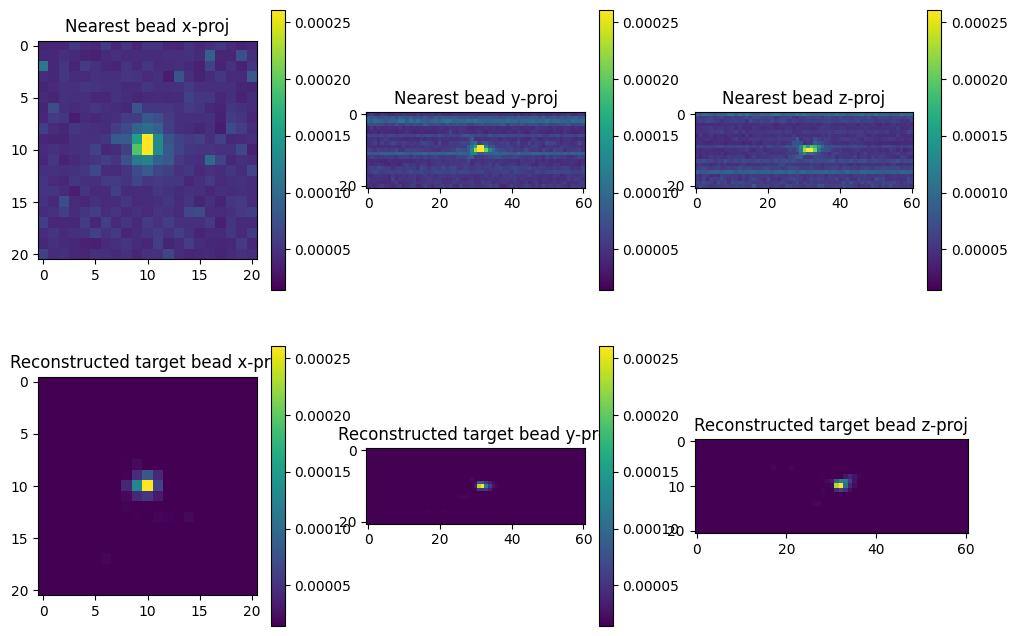

In [89]:
# plot the reconstructed bead volume projections and compare with the nearest bead
nearest_bead_idx = selected_idx[0]
nearest_bead_volume = bead_volumes[nearest_bead_idx, :, :, :]
fig = plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt.imshow(np.max(nearest_bead_volume, axis=0)[:, :].T, vmin = np.min(nearest_bead_volume), vmax = np.max(nearest_bead_volume)/2)
plt.title("Nearest bead x-proj")
plt.colorbar()
plt.subplot(2,3,2)
plt.imshow(np.max(nearest_bead_volume, axis=1)[:, :].T, vmin = np.min(nearest_bead_volume), vmax = np.max(nearest_bead_volume)/2)
plt.title("Nearest bead y-proj")
plt.colorbar()
plt.subplot(2,3,3)
plt.imshow(np.max(nearest_bead_volume, axis=2)[:, :].T, vmin = np.min(nearest_bead_volume), vmax = np.max(nearest_bead_volume)/2)
plt.title("Nearest bead z-proj")
plt.colorbar()
plt.subplot(2,3,4)
plt.imshow(np.max(bead_reconstructed_target, axis=0)[:, :].T, vmin = np.min(nearest_bead_volume), vmax = np.max(nearest_bead_volume)/2)
plt.title("Reconstructed target bead x-proj")
plt.colorbar()
plt.subplot(2,3,5)
plt.imshow(np.max(bead_reconstructed_target, axis=1)[:, :].T, vmin = np.min(nearest_bead_volume), vmax = np.max(nearest_bead_volume)/2)
plt.title("Reconstructed target bead y-proj")
plt.colorbar()
plt.subplot(2,3,6)
plt.imshow(np.max(bead_reconstructed_target, axis=2)[:, :].T, vmin = np.min(nearest_bead_volume), vmax = np.max(nearest_bead_volume)/2)
plt.title("Reconstructed target bead z-proj")